In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
import pycountry
import geopandas as gpd
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *
from src.hazard_def import *
from src.impact_def import *
from src.ImpactRegistry import Impacts

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# 200 reports 
res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v260925.gpkg'))

col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

col_to_list = ["location", "country", "country_kw", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [5]:
# Import 
world = gpd.read_file(ADMIN_PATH / "ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
# admin1 = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_admin_1_states_provinces/"+'ne_10m_admin_1_states_provinces.shp')
# rivers = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_rivers_lake_centerlines/"+'ne_10m_rivers_lake_centerlines.shp')
# cities = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_populated_places/"+'ne_10m_populated_places.shp')

In [14]:
def get_continent(iso_code, world):
    try:
        return world[world['ISO_A3'] == iso_code]['CONTINENT'].values[0]
    except IndexError:
        return None

In [7]:
continent_offsets = {
    'Africa': (0, -0.20),
    'Asia': (0.15, -0.05),
    'Europe': (-0.15, -0.02),
    'Oceania' : (0.08, 0.02),
    'North America' : (-0.05, -0.15),
    'South America' : (-0.05, -0.02)
}

# Hazard Map

In [55]:
dict_color = {
    # 🔥 Environmental & Climatic
    'Drought': '#C2B280',                # sandy beige — dry/arid land
    'Wildfire': '#D1495B',               # strong red — fire and danger
    'Extreme warm temperature': '#E26D5A',# coral/orange — heat
    'Extreme cold temperature': '#A6CEE3',# icy blue — cold

    # 🌋 Geophysical
    'Earthquake': '#7F7F7F',             # neutral gray — ground rupture
    'Mass movement': '#8C564B',          # earthy brown — landslides
    'Volcanic activity': '#E17C05',      # lava orange — volcanic tones

    # 🌊 Hydrological / Meteorological
    'Flood': '#1F77B4',                  # deep blue — water/flood
    'Wave action': '#17BECF',            # cyan — ocean/wave
    'Tropical storm': '#2CA02C',         # green — tropical vegetation/storm
    'Convective storm': '#5B8E7D',       # teal — thunderstorm tone
    'Other storm': '#BCBD22',            # olive — extratropical/windstorm

    # ☣️ Biological / Social
    'Epidemic': '#E377C2',               # magenta — biological hazard
    'Conflict': '#7F3121'                # dark red-brown — violence/unrest
}

hazard_order = list(dict_color.keys())

In [19]:
all_reports_grp = df_llm_all_geo.explode('iso3_code').groupby('appealCode').agg(iso_code = ("iso3_code", "first")).reset_index()

In [32]:
all_reports_country_count = all_reports_grp.groupby("iso_code").agg(appeal_count = ("appealCode", "nunique"))

In [33]:
# df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])
world_2 = world.merge(all_reports_country_count, how="left", left_on="ISO_A3", right_on="iso_code")

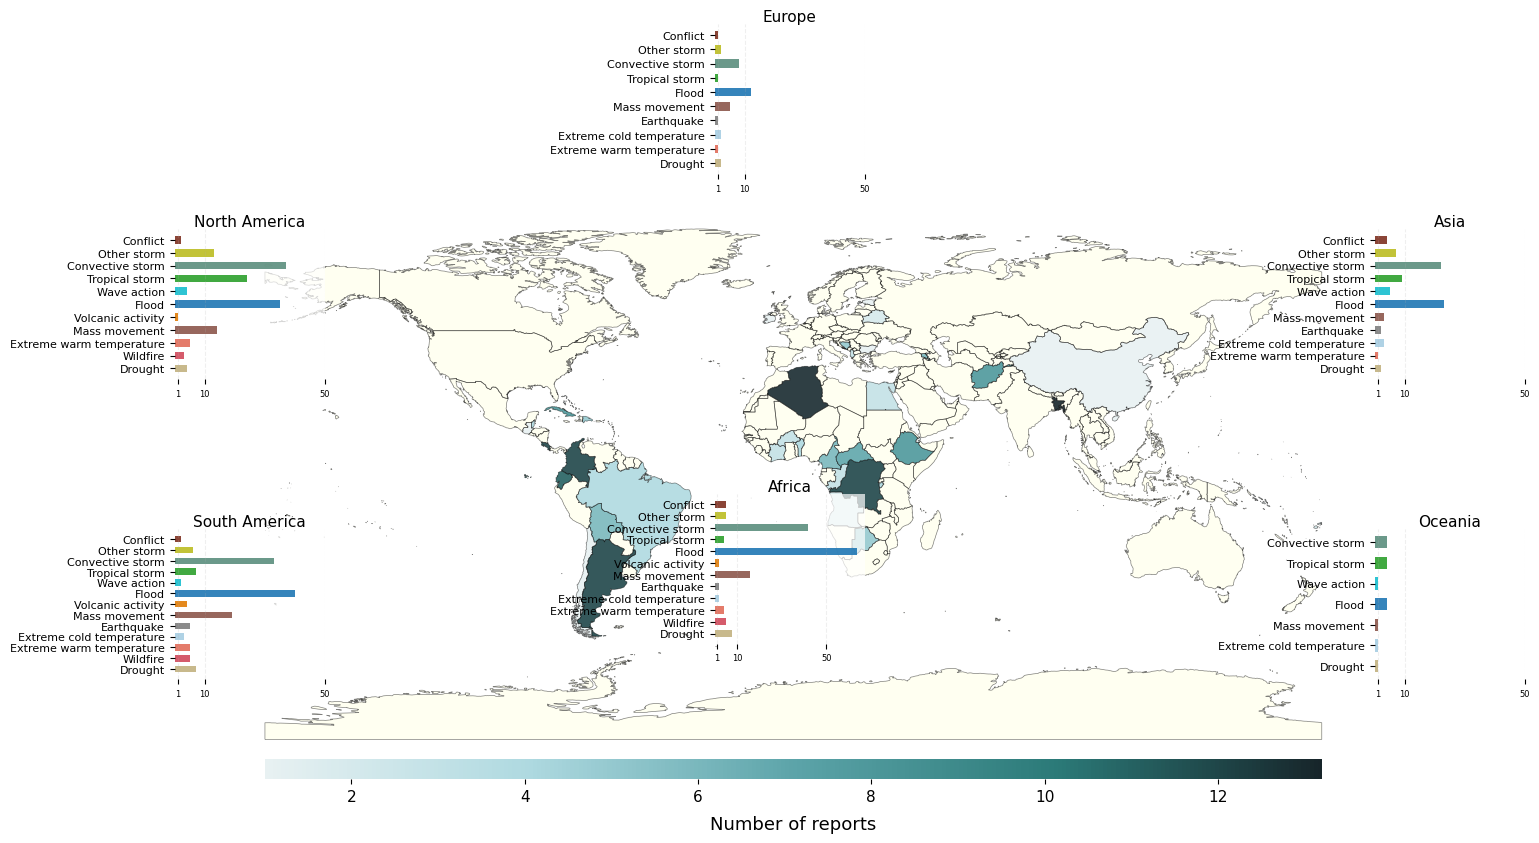

In [66]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world_2.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "neutral_blue_sequential",
#     ["#E0FBFC", "#5C8EAD", "#2A9D8F", "#264653"],
#     N=256
# )
# world_plot = world_2.plot(column="appeal_count",
#                         ax=ax,
#                         legend=False,
#                         cmap=sequential_cmap,
#                         missing_kwds={
#                             "color": "ivory",
#                             "label": "No data"
#                         }, alpha=0.5)

# # Reduce the size of the colorbar
# sm = plt.cm.ScalarMappable(cmap=sequential_cmap, norm=plt.Normalize(vmin=world_2['appeal_count'].min(), vmax=world_2['appeal_count'].max()))
# sm._A = []  # Dummy array for ScalarMappable
# cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label("Number of reports", fontsize=14)

sequential_cmap = LinearSegmentedColormap.from_list(
    "blue_teal_seq",
    ["#E8F1F2", "#AED9E0", "#5CA4A9", "#2B7A78", "#17252A"],  # light → dark
    N=256
)

# Normalize appeal_count to emphasize variation (especially if skewed)
norm = Normalize(
    vmin=world_2["appeal_count"].quantile(0.02),  # ignore extreme low outliers
    vmax=world_2["appeal_count"].quantile(0.98)   # ignore extreme highs
)

# --- Choropleth plot ---
world_plot = world_2.plot(
    column="appeal_count",
    ax=ax,
    legend=False,
    cmap=sequential_cmap,
    norm=norm,
    missing_kwds={
        "color": "ivory",
        "label": "No data"
    },
    alpha=0.9
)

# --- Adjusted colorbar (smaller, cleaner, readable) ---
sm = cm.ScalarMappable(cmap=sequential_cmap, norm=norm)
sm._A = []  # Dummy array for colorbar creation

cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")

# --- Labels & style ---
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("Number of reports", fontsize=13, labelpad=8)

######## ADD HAZARD INFORMATION 
ax.set_axis_off()

df_llm_all_geo['continent'] = df_llm_all_geo['iso3_code'].apply(
    lambda iso_list: list({get_continent(iso) for iso in iso_list if iso}) 
    if isinstance(iso_list, list) else None
)

# Filter out rows without continent
valid_continents = df_llm_all_geo.dropna(subset=['continent'])

# Group by continent and hazard type
df = valid_continents.explode('continent').explode('hazards')

# Drop rows with missing values (optional)
df = df.dropna(subset=['continent', 'hazards'])

# Drop duplicates to count each appeal only once per continent/hazard
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

# Make the plot
# Reprojected centroids and figure assumed defined:
# fig, world_2, continent_centroids, hazard_counts

continent_shapes = world_2.dissolve(by='CONTINENT')#.to_crs('ESRI:54030')
# continent_centroids = continent_shapes.geometry.centroid
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid

# Reproject centroids back to original CRS (WGS84) to overlay on the map
continent_centroids = continent_centroids_proj.to_crs(world_2.crs)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in hazard_counts.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    try:
        # Determine subplot position offsets
        x_offset, y_offset = continent_offsets.get(continent, (0, 0))
        if continent in ['North America', 'South America']:
            x_value = 0.1
        elif continent in ['Asia', 'Oceania']:
            x_value = 0.9
        else:
            x_value = 0.46

        if continent in ['North America', 'Asia']:
            y_value = 0.6
        elif continent in ['South America', 'Oceania']:
            y_value = 0.3
        else:
            y_value = (centroid.y + 90) / 180 + y_offset  # approximate normalization

        # Create a small axis for the bar plot
        ax_bar = fig.add_axes([x_value, y_value, 0.1, 0.15])
        ax_bar.set_facecolor('white')
        ax_bar.patch.set_alpha(0.7)

        # Get hazard data for the continent
        data = hazard_counts.loc[continent]
        data = data[data > 0]  # keep only nonzero categories
        if data.empty:
            continue
        data = data.reindex(hazard_order)
        data = data.dropna()

        # Prepare data
        hazards = data.index
        values = data.values

        # Assign colors with fallback to gray if missing in dict
        colors = [dict_color.get(h, '#BBBBBB') for h in hazards]

        # Plot horizontal bars
        ax_bar.barh(
            y=np.arange(len(values)),
            width=values,
            color=colors,
            alpha=0.9,
            height=0.6
        )

        # Titles and labels
        ax_bar.set_title(continent, fontsize=11, pad=2)
        ax_bar.title.set_position([0.5, 1.1])
        ax_bar.set_yticks(range(len(hazards)))
        ax_bar.set_yticklabels(hazards, fontsize=8)
        # ax_bar.set_xscale('log')
        ax_bar.set_xticks([1, 10, 50])
        ax_bar.tick_params(axis='x', labelsize=6)
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.grid(axis='x', alpha=0.2, linestyle='--')

    except Exception as e:
        print(f"⚠️ Error plotting {continent}: {e}")
        continue


# Impact Map

In [24]:
impact_colormap = {
    'Agriculture': '#7FBF7F',                       # Greenish — crops, livestock
    'Economic Activity & Livelihood Production': '#FDBE85',  # Orange — economy/business
    'Human': '#E34A33',                             # Red — human impacts
    'Infrastructure': '#6BAED6',                    # Blue — buildings, roads, utilities
    'Service access': '#BC80BD'                     # Purple — access to services
}

In [25]:
# Step 0: Get mapping dict from subtype → main type
impact_subtype_to_main = Impacts.get_main_types()  # Already a dict

# Step 1: Map each impactSubtype in your DataFrame
df_llm_all_geo['impact_main_type'] = df_llm_all_geo['impactSubtype'].map(impact_subtype_to_main)

# Optional: check for unmapped subtypes
unmapped = df_llm_all_geo.loc[df_llm_all_geo['impact_main_type'].isna(), 'impactSubtype'].unique()
if len(unmapped) > 0:
    print("⚠️ Unmapped impact subtypes:", unmapped)

# --- Step 2: Now you can safely count per appeal ---
all_report_count = (
    df_llm_all_geo
    .explode('iso3_code')
    .groupby(['appealCode', "impact_main_type"])
    .agg(
        impact_number=("impactSubtype", "count"),   # total number of impact entries
        iso_code=("iso3_code", "first")
    )
    .reset_index()
)

⚠️ Unmapped impact subtypes: ['Informal settlements']


In [26]:
all_report_impact_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()

In [27]:
all_report_impact_count.head()

,iso_code,impact_main_type,impact_count
0,AFG,Agriculture,8
1,AFG,Economic Activity & Livelihood Production,3
2,AFG,Human,45
3,AFG,Infrastructure,25
4,AFG,Service access,35


In [28]:
world_impact = world.merge(all_report_impact_count, how="left", left_on="ISO_A3", right_on="iso_code")

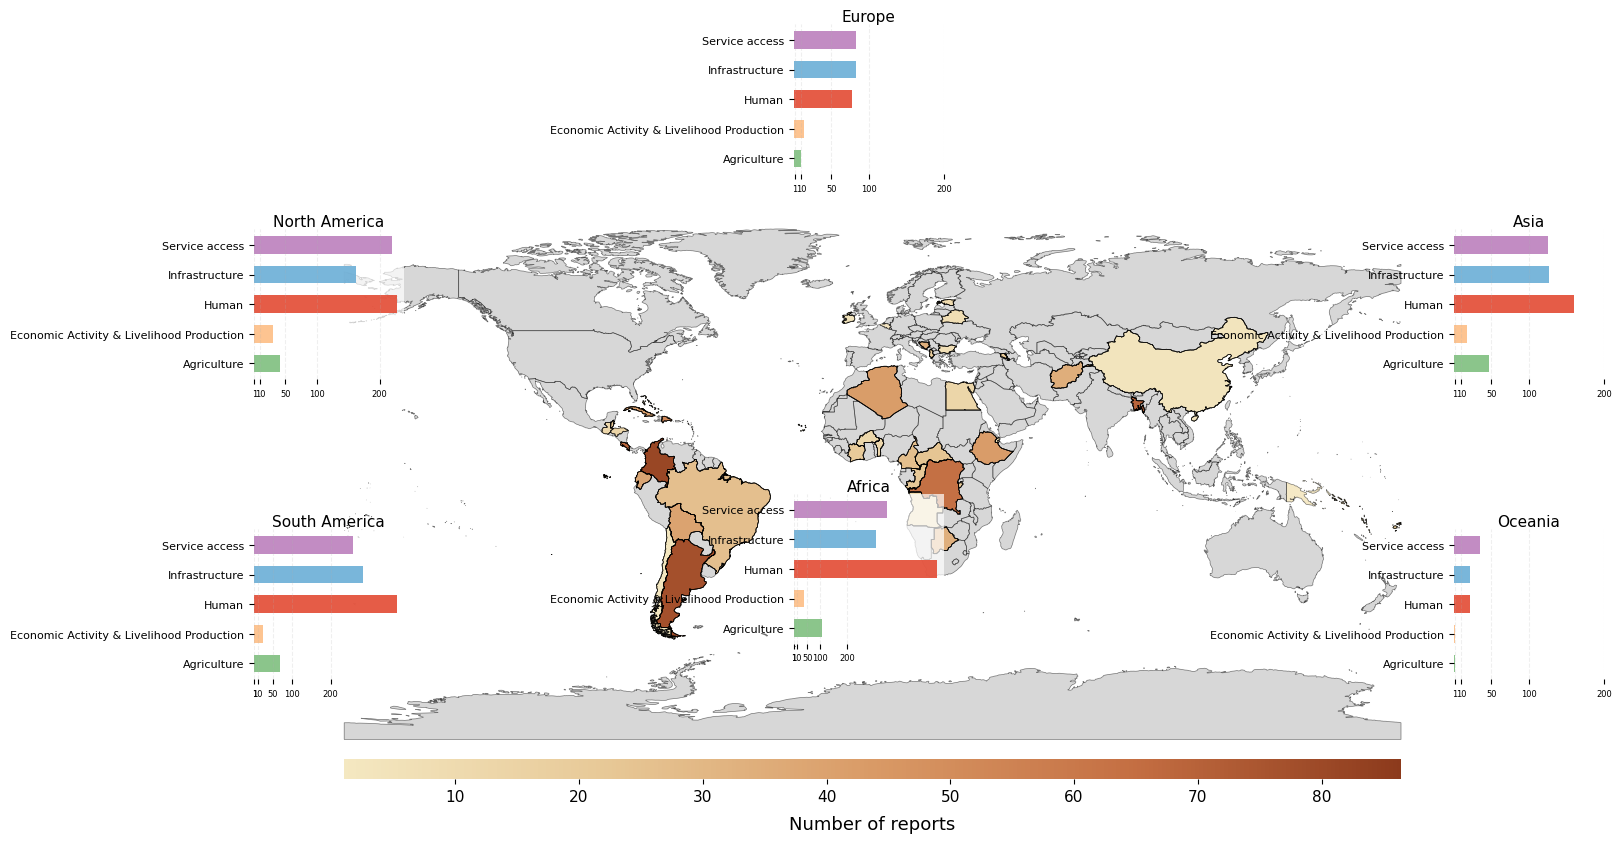

In [20]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world_impact.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "neutral_blue_sequential",
#     ["#E0FBFC", "#5C8EAD", "#2A9D8F", "#264653"],
#     N=256
# )
# world_plot = world_2.plot(column="appeal_count",
#                         ax=ax,
#                         legend=False,
#                         cmap=sequential_cmap,
#                         missing_kwds={
#                             "color": "ivory",
#                             "label": "No data"
#                         }, alpha=0.5)

# # Reduce the size of the colorbar
# sm = plt.cm.ScalarMappable(cmap=sequential_cmap, norm=plt.Normalize(vmin=world_2['appeal_count'].min(), vmax=world_2['appeal_count'].max()))
# sm._A = []  # Dummy array for ScalarMappable
# cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label("Number of reports", fontsize=14)

# sequential_cmap = LinearSegmentedColormap.from_list(
#     "blue_teal_seq",
#     ["#E8F1F2", "#AED9E0", "#5CA4A9", "#2B7A78", "#17252A"],  # light → dark
#     N=256
# )

sequential_cmap = LinearSegmentedColormap.from_list(
    "warm_earth_seq",
    ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"],  # sand → clay → terracotta
    N=256
)

# Normalize appeal_count to emphasize variation (especially if skewed)
norm = Normalize(
    vmin=world_impact["impact_count"].quantile(0.02),  # ignore extreme low outliers
    vmax=world_impact["impact_count"].quantile(0.98)   # ignore extreme highs
)

# --- Choropleth plot ---
world_plot = world_impact.plot(
    column="impact_count",
    ax=ax,
    legend=False,
    cmap=sequential_cmap,
    norm=norm,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# --- Adjusted colorbar (smaller, cleaner, readable) ---
sm = cm.ScalarMappable(cmap=sequential_cmap, norm=norm)
sm._A = []  # Dummy array for colorbar creation

cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")

# --- Labels & style ---
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("Number of reports", fontsize=13, labelpad=8)

######## ADD HAZARD INFORMATION 
ax.set_axis_off()

all_report_impact_count['continent'] = all_report_impact_count['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)
all_report_impact_count = all_report_impact_count.set_index("continent")

# Make the plot
# Reprojected centroids and figure assumed defined:
# fig, world_2, continent_centroids, hazard_counts

continent_shapes = world_impact.dissolve(by='CONTINENT')#.to_crs('ESRI:54030')
# continent_centroids = continent_shapes.geometry.centroid
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid

# Reproject centroids back to original CRS (WGS84) to overlay on the map
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

continent_impact_counts = (
    all_report_impact_count
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns according to impact_colormap
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)

# # --- Step 2: Plot choropleth as before ---
# fig, ax = plt.subplots(1, 1, figsize=(15, 10))
# world_impact.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "blue_teal_seq",
#     ["#E8F1F2", "#AED9E0", "#5CA4A9", "#2B7A78", "#17252A"],  # light → dark
#     N=256
# )
# norm = Normalize(
#     vmin=world_impact["impact_count"].quantile(0.02),
#     vmax=world_impact["impact_count"].quantile(0.98)
# )
# world_impact.plot(
#     column="impact_count",
#     ax=ax,
#     legend=False,
#     cmap=sequential_cmap,
#     norm=norm,
#     missing_kwds={"color": "ivory", "label": "No data"},
#     alpha=0.9
# )
# sm = cm.ScalarMappable(cmap=sequential_cmap, norm=norm)
# sm._A = []
# cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=11)
# cbar.outline.set_visible(False)
# cbar.set_label("Number of reports", fontsize=13, labelpad=8)
# ax.set_axis_off()

# --- Step 3: Add mini bar plots for impact types per continent ---
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_counts.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    try:
        # Determine subplot offsets
        x_offset, y_offset = continent_offsets.get(continent, (0, 0))
        if continent in ['North America', 'South America']:
            x_value = 0.1
        elif continent in ['Asia', 'Oceania']:
            x_value = 0.9
        else:
            x_value = 0.46

        if continent in ['North America', 'Asia']:
            y_value = 0.6
        elif continent in ['South America', 'Oceania']:
            y_value = 0.3
        else:
            y_value = (centroid.y + 90) / 180 + y_offset

        # Create a small axis for the bar plot
        ax_bar = fig.add_axes([x_value, y_value, 0.1, 0.15])
        ax_bar.set_facecolor('white')
        ax_bar.patch.set_alpha(0.7)

        # Get continent-level data
        data = continent_impact_counts.loc[continent]
        data = data[data > 0]  # remove zero categories

        impacts = data.index
        values = data.values
        colors = [impact_colormap.get(i, '#BBBBBB') for i in impacts]

        # Plot horizontal bars
        ax_bar.barh(
            y=np.arange(len(values)),
            width=values,
            color=colors,
            alpha=0.9,
            height=0.6
        )

        # Labels and title
        ax_bar.set_title(continent, fontsize=11, pad=2)
        ax_bar.title.set_position([0.5, 1.1])
        ax_bar.set_yticks(range(len(impacts)))
        ax_bar.set_yticklabels(impacts, fontsize=8)
        ax_bar.set_xticks([1, 10, 50, 100, 200])
        ax_bar.tick_params(axis='x', labelsize=6)
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.grid(axis='x', alpha=0.2, linestyle='--')

    except Exception as e:
        print(f"⚠️ Error plotting {continent}: {e}")
        continue

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_9288\2520348084.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


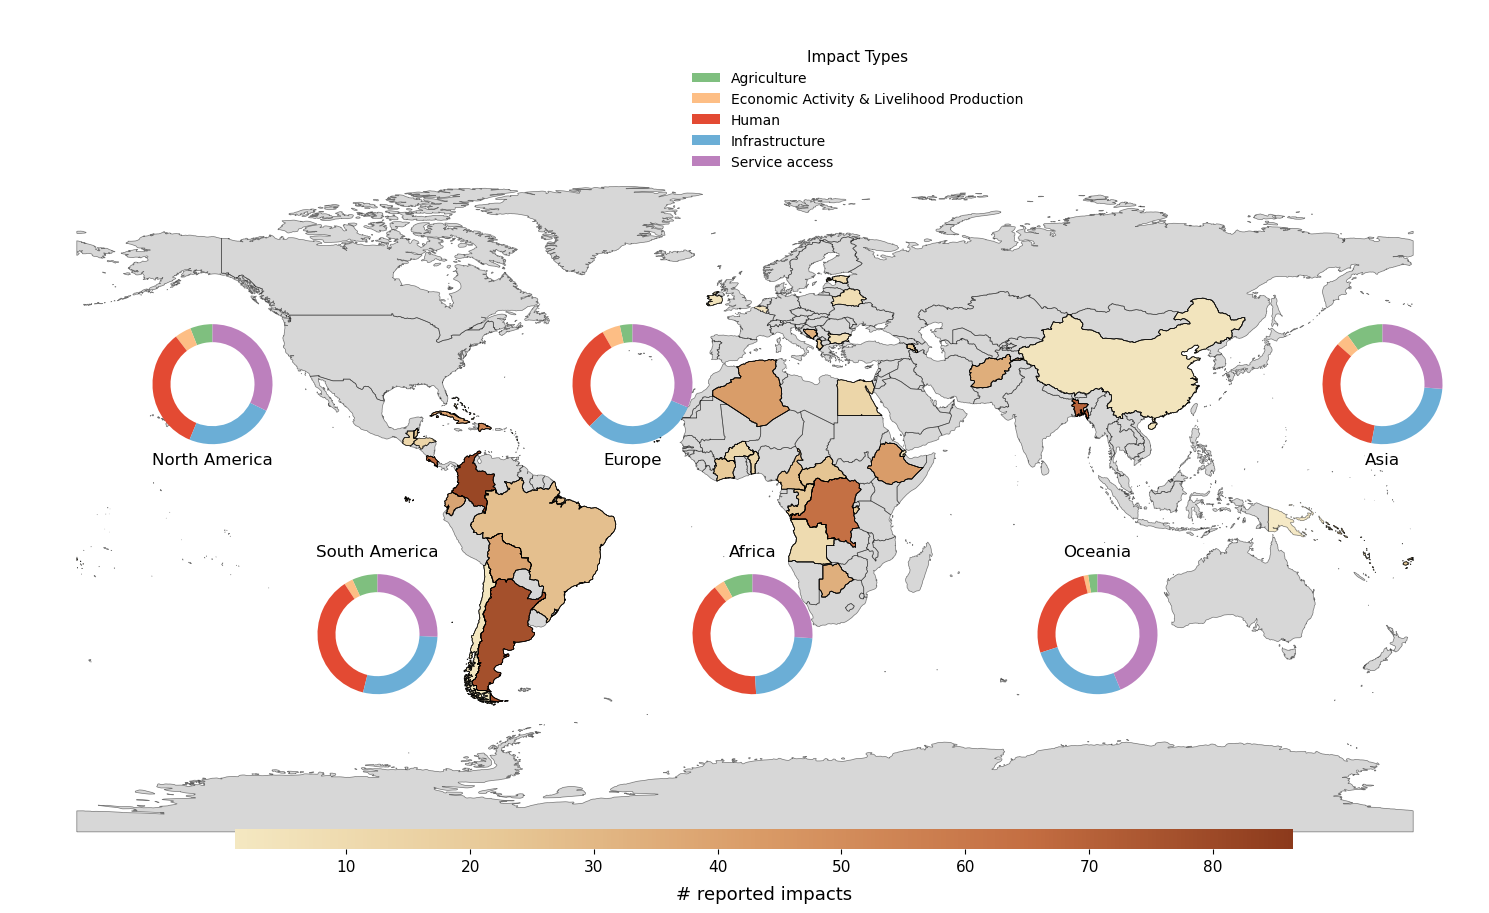

In [ ]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world_impact.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)

# Color map for choropleth
sequential_cmap = LinearSegmentedColormap.from_list(
    "warm_earth_seq",
    ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"],
    N=256
)

# Normalize appeal_count
norm = Normalize(
    vmin=world_impact["impact_count"].quantile(0.02),
    vmax=world_impact["impact_count"].quantile(0.98)
)

# Choropleth plot
world_plot = world_impact.plot(
    column="impact_count",
    ax=ax,
    legend=False,
    cmap=sequential_cmap,
    norm=norm,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=sequential_cmap, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.16, 0.16, 0.705, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("# reported impacts", fontsize=13, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.43, 0.3),
    'Asia': (0.85, 0.57),
    'Europe': (0.33, 0.57),
    'North America': (0.07, 0.57),
    'Oceania': (0.66, 0.3),
    'South America': (0.18, 0.3)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))
    
    # Position donut charts around the map
    # if continent in ['North America', 'South America']:
    #     x_value = 0.1
    # elif continent in ['Asia', 'Oceania']:
    #     x_value = 0.9
    # else:
    #     x_value = 0.46

    # if continent in ['North America', 'Asia']:
    #     y_value = 0.6
    # elif continent in ['South America', 'Oceania']:
    #     y_value = 0.3
    # else:
    #     y_value = (centroid.y + 90) / 180 + y_offset

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.15, 0.15])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)

    # Get percentage data
    data = continent_impact_pct.loc[continent]
    data = data[data > 0]  # Remove zero categories
    
    if len(data) == 0:
        continue
        
    labels = data.index
    sizes = data.values
    colors = [impact_colormap.get(label, '#BBBBBB') for label in labels]

    # Create donut chart
    wedges, _ = ax_donut.pie(sizes, colors=colors, startangle=90, wedgeprops=dict(width=0.3))
    
    # Add percentage labels for significant slices (>10%)
    for i, (size, wedge) in enumerate(zip(sizes, wedges)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.6 * np.cos(np.radians(angle))
            y = 0.6 * np.sin(np.radians(angle))
            # ax_donut.text(x, y, f'{size:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold')
    
    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe'] :
        ax_donut.set_title(continent, fontsize=12, pad=2, y=-0.05)
        # ax_donut.title.set_position([0.5, 0.1])
        # ax_donut.title.set_y(-0.1)
    else : 
        ax_donut.set_title(continent, fontsize=12, pad=2, y=1)
        # ax_donut.title.set_position([0.5, 1.1])
        # ax_donut.title.set_y(1.1)

# Add legend for impact types
legend_ax = fig.add_axes([0.5, 0.8, 0.15, 0.2])
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements
legend_elements = [plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=impact) 
                  for impact in impact_order if impact in impact_colormap]

legend_ax.legend(handles=legend_elements, loc='center', frameon=False, 
                fontsize=10, title='Impact Types', title_fontsize=11)
legend_ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
all_report_impact_count

,iso_code,impact_main_type,impact_count,continent
continent,,,,
Asia,AFG,Agriculture,8,Asia
Asia,AFG,Economic Activity & Livelihood Production,3,Asia
Asia,AFG,Human,45,Asia
Asia,AFG,Infrastructure,25,Asia
Asia,AFG,Service access,35,Asia
...,...,...,...,...
Oceania,PNG,Agriculture,2,Oceania
Oceania,SLB,Human,12,Oceania
Oceania,SLB,Service access,15,Oceania
